Import Library

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
df = pd.read_csv('/content/plant_disease_dataset.csv')

df.head()

,temperature,humidity,rainfall,soil_pH,disease_present
0,27.483571,33.215053,0.572758,4.975875,1
1,24.308678,36.945005,42.522346,8.165266,0
2,28.238443,34.026189,16.095303,6.316734,1
3,32.615149,41.104180,20.311015,6.164949,0
4,23.829233,51.971785,11.851323,8.482468,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temperature      10000 non-null  float64
 1   humidity         10000 non-null  float64
 2   rainfall         10000 non-null  float64
 3   soil_pH          10000 non-null  float64
 4   disease_present  10000 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 390.8 KB


In [6]:
df.describe()

,temperature,humidity,rainfall,soil_pH,disease_present
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25.612191,62.119300,9.807522,6.245855,0.241000
std,5.813841,22.679977,9.852130,1.302465,0.427712
min,5.387999,6.244209,0.000055,4.000075,0.000000
25%,21.815610,40.772925,2.812822,5.122970,0.000000
50%,25.293238,72.211752,6.864898,6.232188,0.000000
75%,28.916048,81.032999,13.442871,7.386377,0.000000
max,56.686495,102.395421,84.654161,8.499875,1.000000


In [7]:
df.isnull().sum()

,0
temperature,0
humidity,0
rainfall,0
soil_pH,0
disease_present,0


In [8]:
df.duplicated().sum()

np.int64(0)

EDA Histogram

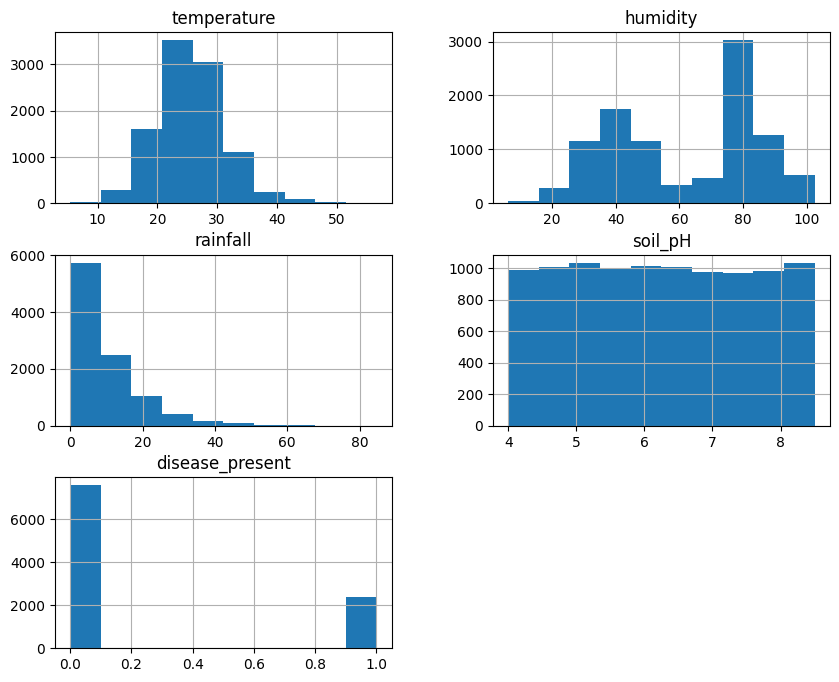

In [9]:
df.hist(figsize=(10,8))
plt.show()

Heatmap

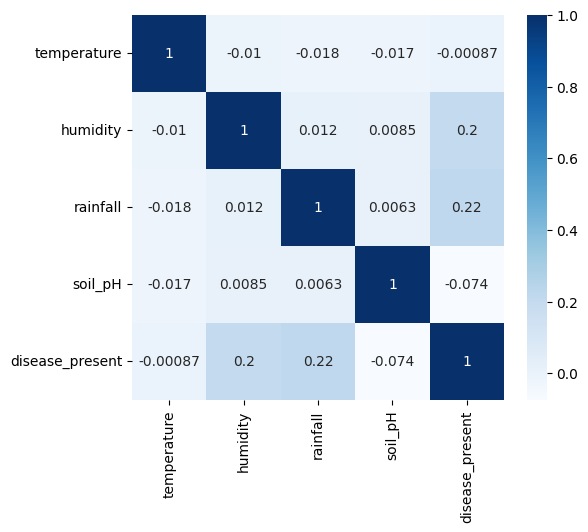

In [10]:
plt.figure(figsize=(6,5))

sns.heatmap(df.corr(),annot=True,cmap="Blues")

plt.show()

Bar Chart

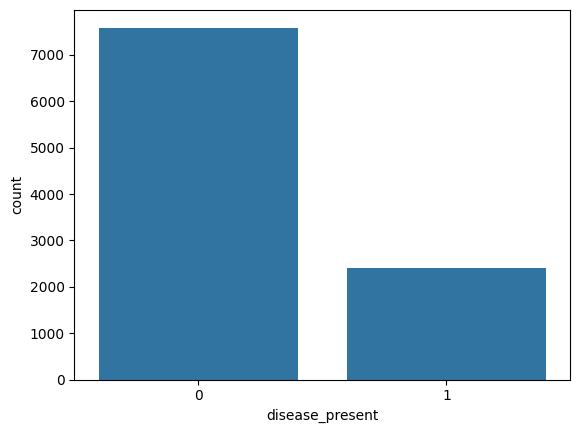

In [11]:
sns.countplot(x="disease_present",data=df)

plt.show()

Split Data

In [12]:
X=df.drop("disease_present",axis=1)

y=df["disease_present"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 4)
(2000, 4)


Normalisasi

In [13]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

print("Normalisasi berhasil")

Normalisasi berhasil


Decision Tree

In [14]:
# Membuat model Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Melatih model
dt_model.fit(X_train, y_train)

# Prediksi data testing
dt_pred = dt_model.predict(X_test)

print("Model Decision Tree berhasil dibuat")

Model Decision Tree berhasil dibuat


In [15]:
# Menghitung akurasi Decision Tree
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Akurasi Decision Tree :", round(dt_accuracy * 100, 2), "%")

Akurasi Decision Tree : 77.2 %


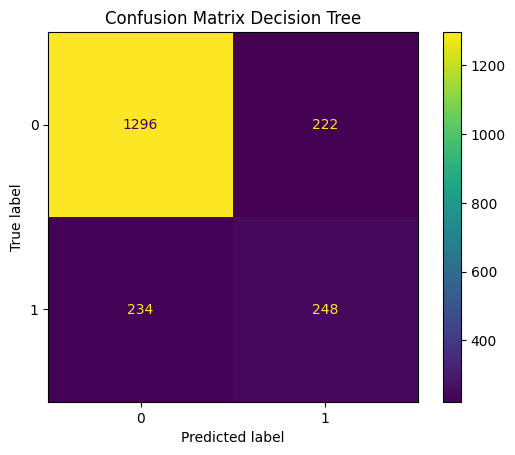

In [16]:
# Confusion Matrix Decision Tree
ConfusionMatrixDisplay.from_estimator(dt_model, X_test, y_test)

plt.title("Confusion Matrix Decision Tree")
plt.show()

In [17]:
# Classification Report Decision Tree
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1518
           1       0.53      0.51      0.52       482

    accuracy                           0.77      2000
   macro avg       0.69      0.68      0.69      2000
weighted avg       0.77      0.77      0.77      2000



K-Nearest Neighbor (KNN)

In [18]:
# Membuat model KNN
knn_model = KNeighborsClassifier(n_neighbors=5)

# Melatih model
knn_model.fit(X_train, y_train)

# Prediksi data testing
knn_pred = knn_model.predict(X_test)

print("Model KNN berhasil dibuat")

Model KNN berhasil dibuat


In [19]:
# Menghitung akurasi KNN
knn_accuracy = accuracy_score(y_test, knn_pred)

print("Akurasi KNN :", round(knn_accuracy * 100, 2), "%")

Akurasi KNN : 83.25 %


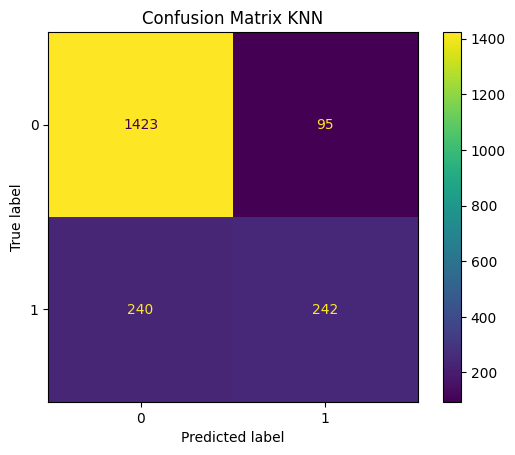

In [20]:
# Confusion Matrix KNN
ConfusionMatrixDisplay.from_estimator(knn_model, X_test, y_test)

plt.title("Confusion Matrix KNN")
plt.show()

In [21]:
# Classification Report KNN
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.86      0.94      0.89      1518
           1       0.72      0.50      0.59       482

    accuracy                           0.83      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.82      0.83      0.82      2000



Perbandingan Model

In [22]:
# Membandingkan akurasi kedua model
hasil = {
    "Algoritma": ["Decision Tree", "K-Nearest Neighbor"],
    "Accuracy": [dt_accuracy * 100, knn_accuracy * 100]
}

hasil_df = pd.DataFrame(hasil)

print(hasil_df)

            Algoritma  Accuracy
0       Decision Tree     77.20
1  K-Nearest Neighbor     83.25


Grafik Perbandingan

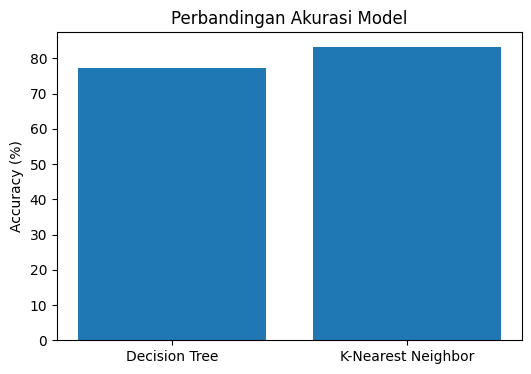

In [23]:
plt.figure(figsize=(6,4))

plt.bar(
    hasil_df["Algoritma"],
    hasil_df["Accuracy"]
)

plt.title("Perbandingan Akurasi Model")
plt.ylabel("Accuracy (%)")

plt.show()